# Pair-Level Cannabis Reddit Analysis

This notebook analyzes the cleaned pair-level GPT-4.1-mini output directly. It uses one row per extracted `(product, sentiment)` pair and does not use week labels or text-level modeling data.


The annotated input was a 10,000-row time-aware sample from the cleaned Reddit data. Records were sorted by time and sampled across the available date range, rather than using the first 10,000 rows. This keeps multiple time periods represented for temporal analysis.

Target schema: `text_id | product | sentiment | date_utc`.


## 1. Load Pair-Level Data

Load the cleaned final CSV and validate that it matches the expected schema and label space.


In [16]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path('data/final/pair_level_gpt41mini_clean.csv')
OUT_DIR = Path('data/final/analysis_outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_COLUMNS = ['text_id', 'product', 'sentiment', 'date_utc']
ALLOWED_PRODUCTS = {'flower', 'oil', 'gummies', 'vape', 'topical'}
ALLOWED_SENTIMENTS = {'positive', 'negative', 'neutral'}
SENTIMENT_ORDER = ['negative', 'neutral', 'positive']
PRODUCT_ORDER = ['flower', 'oil', 'gummies', 'vape', 'topical']

pair_df = pd.read_csv(DATA_PATH)
pair_df = pair_df[EXPECTED_COLUMNS].copy()

for col in EXPECTED_COLUMNS:
    pair_df[col] = pair_df[col].astype('string').str.strip()

pair_df['date_utc'] = pd.to_datetime(pair_df['date_utc'], utc=True, errors='coerce')
pair_df['year_month'] = pair_df['date_utc'].dt.to_period('M').astype(str)
pair_df['year'] = pair_df['date_utc'].dt.year

missing_required = pair_df[['product', 'sentiment']].isna().sum()
blank_required = (pair_df[['product', 'sentiment']] == '').sum()
bad_products = sorted(set(pair_df['product'].dropna()) - ALLOWED_PRODUCTS)
bad_sentiments = sorted(set(pair_df['sentiment'].dropna()) - ALLOWED_SENTIMENTS)

assert list(pair_df.columns[:len(EXPECTED_COLUMNS)]) == EXPECTED_COLUMNS
assert missing_required.sum() == 0, missing_required
assert blank_required.sum() == 0, blank_required
assert not bad_products, bad_products
assert not bad_sentiments, bad_sentiments
assert pair_df['date_utc'].notna().all()

print('pair_df shape:', pair_df.shape)
print('date range:', pair_df['date_utc'].min(), 'to', pair_df['date_utc'].max())
pair_df.head()

pair_df shape: (7031, 6)
date range: 2022-01-01 04:45:21+00:00 to 2024-12-27 17:33:45+00:00


/tmp/tmp.YUPVaX9CLx/ipykernel_502810/602290719.py:23: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  pair_df['year_month'] = pair_df['date_utc'].dt.to_period('M').astype(str)


,text_id,product,sentiment,date_utc,year_month,year
0,hqrt7lw,vape,positive,2022-01-01 04:45:21+00:00,2022-01,2022
1,hqs1aeh,vape,neutral,2022-01-01 06:10:06+00:00,2022-01,2022
2,hqs1aeh,oil,neutral,2022-01-01 06:10:06+00:00,2022-01,2022
3,hqs7u29,oil,neutral,2022-01-01 07:26:39+00:00,2022-01,2022
4,hqs7u29,flower,neutral,2022-01-01 07:26:39+00:00,2022-01,2022


## 2. Dataset Overview

Summarize the size of the pair-level dataset, the number of unique Reddit texts, the date range.


In [17]:
overview = pd.DataFrame({
    'metric': [
        'pair_rows',
        'unique_text_id',
        'start_date_utc',
        'end_date_utc',
        'months_covered',
    ],
    'value': [
        len(pair_df),
        pair_df['text_id'].nunique(),
        pair_df['date_utc'].min().strftime('%Y-%m-%d'),
        pair_df['date_utc'].max().strftime('%Y-%m-%d'),
        pair_df['year_month'].nunique(),
    ],
})
overview.to_csv(OUT_DIR / 'overview.csv', index=False)
display(overview)

,metric,value
0,pair_rows,7031
1,unique_text_id,4401
2,start_date_utc,2022-01-01
3,end_date_utc,2024-12-27
4,months_covered,36


## 3. Product and Sentiment Distributions

Inspect how many extracted pairs belong to each product and sentiment label.


In [18]:
product_counts = (
    pair_df['product']
    .value_counts()
    .reindex(PRODUCT_ORDER, fill_value=0)
    .rename_axis('product')
    .reset_index(name='n_pairs')
)
product_counts['share'] = product_counts['n_pairs'] / product_counts['n_pairs'].sum()
product_counts.to_csv(OUT_DIR / 'product_counts.csv', index=False)

def ordered_sentiment_counts(df):
    out = df['sentiment'].value_counts().reindex(SENTIMENT_ORDER, fill_value=0)
    return out.rename_axis('sentiment').reset_index(name='n_pairs')

sentiment_counts = ordered_sentiment_counts(pair_df)
sentiment_counts['share'] = sentiment_counts['n_pairs'] / sentiment_counts['n_pairs'].sum()
sentiment_counts.to_csv(OUT_DIR / 'sentiment_counts.csv', index=False)

display(product_counts)
display(sentiment_counts)

,product,n_pairs,share
0,flower,1575,0.224008
1,oil,1816,0.258285
2,gummies,1812,0.257716
3,vape,1609,0.228844
4,topical,219,0.031148


,sentiment,n_pairs,share
0,negative,1975,0.280899
1,neutral,1230,0.17494
2,positive,3826,0.544162


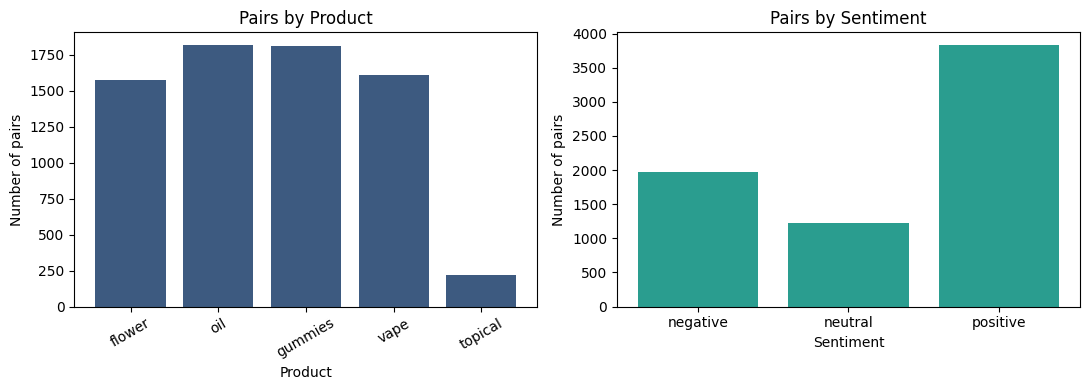

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(product_counts['product'], product_counts['n_pairs'], color='#3d5a80')
axes[0].set_title('Pairs by Product')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Number of pairs')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(sentiment_counts['sentiment'], sentiment_counts['n_pairs'], color='#2a9d8f')
axes[1].set_title('Pairs by Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Number of pairs')

plt.tight_layout()
plt.show()

## 4. Product-Sentiment Relationship

Use count and row-normalized cross-tabs to compare sentiment patterns across products.


In [20]:
product_sentiment_counts = pd.crosstab(pair_df['product'], pair_df['sentiment'])
product_sentiment_counts = product_sentiment_counts.reindex(index=PRODUCT_ORDER, columns=SENTIMENT_ORDER, fill_value=0)
product_sentiment_share = product_sentiment_counts.div(product_sentiment_counts.sum(axis=1), axis=0)

product_sentiment_counts.to_csv(OUT_DIR / 'product_sentiment_counts.csv')
product_sentiment_share.to_csv(OUT_DIR / 'product_sentiment_share.csv')

display(product_sentiment_counts)
display(product_sentiment_share.style.format('{:.1%}'))

sentiment,negative,neutral,positive
product,,,
flower,403,277,895
oil,410,309,1097
gummies,584,302,926
vape,546,297,766
topical,32,45,142


sentiment,negative,neutral,positive
product,,,
flower,25.6%,17.6%,56.8%
oil,22.6%,17.0%,60.4%
gummies,32.2%,16.7%,51.1%
vape,33.9%,18.5%,47.6%
topical,14.6%,20.5%,64.8%


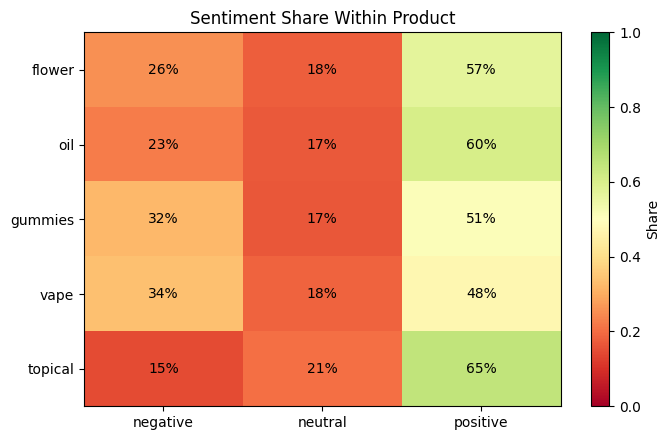

In [21]:
fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(product_sentiment_share.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(len(SENTIMENT_ORDER)), SENTIMENT_ORDER)
ax.set_yticks(range(len(PRODUCT_ORDER)), PRODUCT_ORDER)
ax.set_title('Sentiment Share Within Product')

for i, product in enumerate(PRODUCT_ORDER):
    for j, sentiment in enumerate(SENTIMENT_ORDER):
        ax.text(j, i, f'{product_sentiment_share.loc[product, sentiment]:.0%}', ha='center', va='center')

fig.colorbar(im, ax=ax, label='Share')
plt.tight_layout()
plt.show()

## 5. Multiple Pairs per Text

Because a single Reddit text can mention multiple product-specific opinions, measure how many pair rows are attached to each `text_id`.


In [22]:
pairs_per_text = pair_df.groupby('text_id').size().rename('n_pairs').reset_index()
pairs_per_text_dist = (
    pairs_per_text['n_pairs']
    .value_counts()
    .sort_index()
    .rename_axis('pairs_per_text')
    .reset_index(name='n_texts')
)
pairs_per_text_dist['share_of_texts'] = pairs_per_text_dist['n_texts'] / pairs_per_text_dist['n_texts'].sum()

multi_product_texts = (
    pair_df.groupby('text_id')['product']
    .nunique()
    .rename('n_products')
    .reset_index()
)

pairs_per_text_dist.to_csv(OUT_DIR / 'pairs_per_text_distribution.csv', index=False)
multi_product_texts.to_csv(OUT_DIR / 'products_per_text.csv', index=False)

display(pairs_per_text_dist)
print('Texts with more than one pair:', int((pairs_per_text['n_pairs'] > 1).sum()))
print('Texts with more than one product:', int((multi_product_texts['n_products'] > 1).sum()))

,pairs_per_text,n_texts,share_of_texts
0,1,2413,0.548284
1,2,1467,0.333333
2,3,411,0.093388
3,4,99,0.022495
4,5,11,0.002499


Texts with more than one pair: 1988
Texts with more than one product: 1939


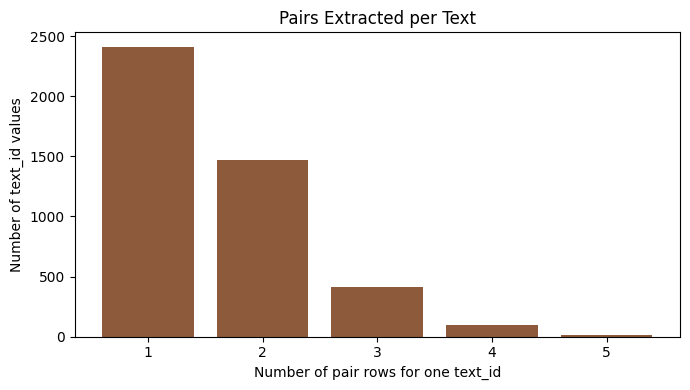

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(pairs_per_text_dist['pairs_per_text'].astype(str), pairs_per_text_dist['n_texts'], color='#8d5a3b')
ax.set_title('Pairs Extracted per Text')
ax.set_xlabel('Number of pair rows for one text_id')
ax.set_ylabel('Number of text_id values')
plt.tight_layout()
plt.show()

## 6. Monthly Product Volume

Track how product-specific pair volume changes over time using `date_utc` converted to month.


In [24]:
monthly_product = (
    pair_df.groupby(['year_month', 'product'])
    .size()
    .reset_index(name='n_pairs')
    .sort_values(['year_month', 'product'])
)
monthly_product_wide = (
    monthly_product.pivot(index='year_month', columns='product', values='n_pairs')
    .reindex(columns=PRODUCT_ORDER)
    .fillna(0)
    .astype(int)
)

monthly_product.to_csv(OUT_DIR / 'monthly_product_counts.csv', index=False)
monthly_product_wide.to_csv(OUT_DIR / 'monthly_product_counts_wide.csv')

display(monthly_product.head())
display(monthly_product_wide.head())

,year_month,product,n_pairs
0,2022-01,flower,51
1,2022-01,gummies,50
2,2022-01,oil,48
3,2022-01,topical,6
4,2022-01,vape,49


product,flower,oil,gummies,vape,topical
year_month,,,,,
2022-01,51,48,50,49,6
2022-02,48,42,45,45,7
2022-03,48,52,41,47,4
2022-04,46,52,47,38,8
2022-05,39,46,56,36,8


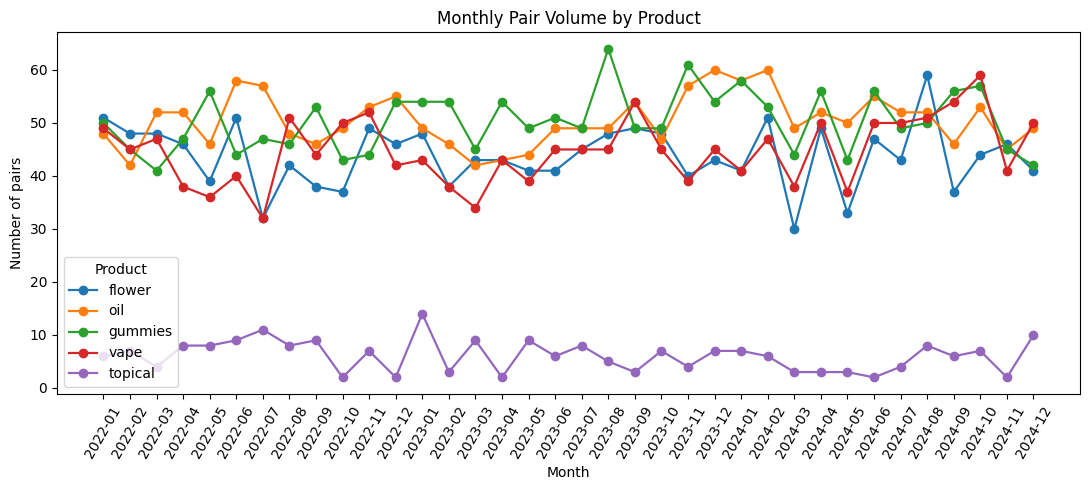

In [25]:
fig, ax = plt.subplots(figsize=(11, 5))
for product in PRODUCT_ORDER:
    ax.plot(monthly_product_wide.index, monthly_product_wide[product], marker='o', linewidth=1.6, label=product)

ax.set_title('Monthly Pair Volume by Product')
ax.set_xlabel('Month')
ax.set_ylabel('Number of pairs')
ax.legend(title='Product')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

## 7. Monthly Sentiment Mix

Track the monthly share of positive, neutral, and negative labels overall and by product.


In [26]:
monthly_sentiment = (
    pair_df.groupby(['year_month', 'sentiment'])
    .size()
    .reset_index(name='n_pairs')
)
monthly_sentiment_wide = (
    monthly_sentiment.pivot(index='year_month', columns='sentiment', values='n_pairs')
    .reindex(columns=SENTIMENT_ORDER)
    .fillna(0)
    .astype(int)
)
monthly_sentiment_share = monthly_sentiment_wide.div(monthly_sentiment_wide.sum(axis=1), axis=0)

monthly_product_sentiment = (
    pair_df.groupby(['year_month', 'product', 'sentiment'])
    .size()
    .reset_index(name='n_pairs')
)
monthly_product_sentiment['month_product_total'] = monthly_product_sentiment.groupby(['year_month', 'product'])['n_pairs'].transform('sum')
monthly_product_sentiment['share'] = monthly_product_sentiment['n_pairs'] / monthly_product_sentiment['month_product_total']

monthly_sentiment_wide.to_csv(OUT_DIR / 'monthly_sentiment_counts_wide.csv')
monthly_sentiment_share.to_csv(OUT_DIR / 'monthly_sentiment_share_wide.csv')
monthly_product_sentiment.to_csv(OUT_DIR / 'monthly_product_sentiment.csv', index=False)

display(monthly_sentiment_share.head().style.format('{:.1%}'))
display(monthly_product_sentiment.head())

sentiment,negative,neutral,positive
year_month,,,
2022-01,28.4%,21.6%,50.0%
2022-02,24.1%,19.8%,56.1%
2022-03,29.2%,12.0%,58.9%
2022-04,31.9%,14.7%,53.4%
2022-05,27.6%,18.4%,54.1%


,year_month,product,sentiment,n_pairs,month_product_total,share
0,2022-01,flower,negative,15,51,0.294118
1,2022-01,flower,neutral,14,51,0.274510
2,2022-01,flower,positive,22,51,0.431373
3,2022-01,gummies,negative,17,50,0.340000
4,2022-01,gummies,neutral,14,50,0.280000


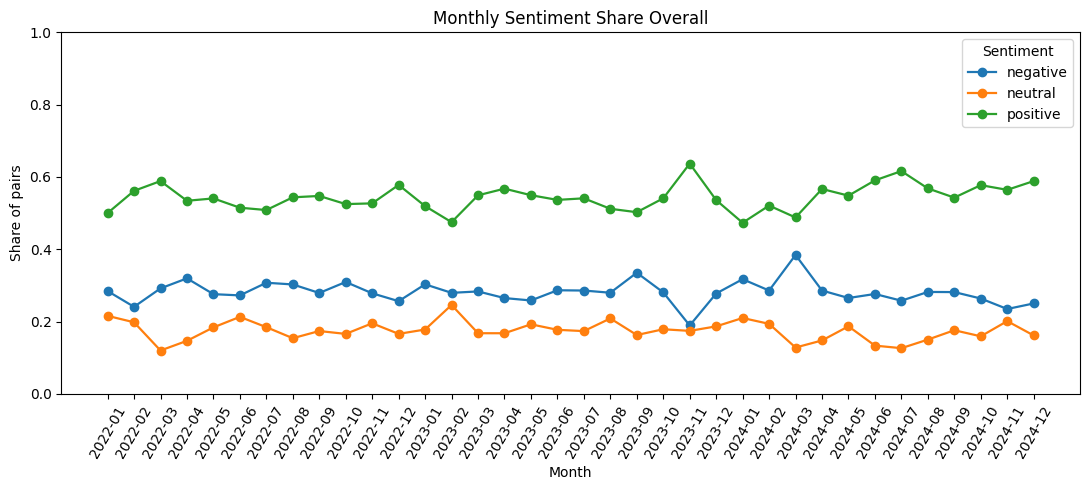

In [27]:
fig, ax = plt.subplots(figsize=(11, 5))
for sentiment in SENTIMENT_ORDER:
    ax.plot(monthly_sentiment_share.index, monthly_sentiment_share[sentiment], marker='o', linewidth=1.6, label=sentiment)

ax.set_title('Monthly Sentiment Share Overall')
ax.set_xlabel('Month')
ax.set_ylabel('Share of pairs')
ax.set_ylim(0, 1)
ax.legend(title='Sentiment')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

## 8. Product-Specific Sentiment Score Trend

Map sentiment to a simple score (`positive = 1`, `neutral = 0`, `negative = -1`) and average by product-month. This gives a compact trend measure without using week labels.


In [28]:
sentiment_score = {'positive': 1, 'neutral': 0, 'negative': -1}
scored = pair_df.copy()
scored['sentiment_score'] = scored['sentiment'].map(sentiment_score)

monthly_score = (
    scored.groupby(['year_month', 'product'])['sentiment_score']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'avg_sentiment_score', 'count': 'n_pairs'})
)
monthly_score_wide = (
    monthly_score.pivot(index='year_month', columns='product', values='avg_sentiment_score')
    .reindex(columns=PRODUCT_ORDER)
)

monthly_score.to_csv(OUT_DIR / 'monthly_product_sentiment_score.csv', index=False)
monthly_score_wide.to_csv(OUT_DIR / 'monthly_product_sentiment_score_wide.csv')

display(monthly_score.head())
display(monthly_score_wide.head())

,year_month,product,avg_sentiment_score,n_pairs
0,2022-01,flower,0.137255,51
1,2022-01,gummies,0.040000,50
2,2022-01,oil,0.291667,48
3,2022-01,topical,0.666667,6
4,2022-01,vape,0.346939,49


product,flower,oil,gummies,vape,topical
year_month,,,,,
2022-01,0.137255,0.291667,0.040000,0.346939,0.666667
2022-02,0.250000,0.380952,0.422222,0.177778,0.714286
2022-03,0.354167,0.538462,-0.048780,0.234043,0.750000
2022-04,0.282609,0.211538,0.191489,0.131579,0.375000
2022-05,0.435897,0.369565,0.071429,0.083333,1.000000


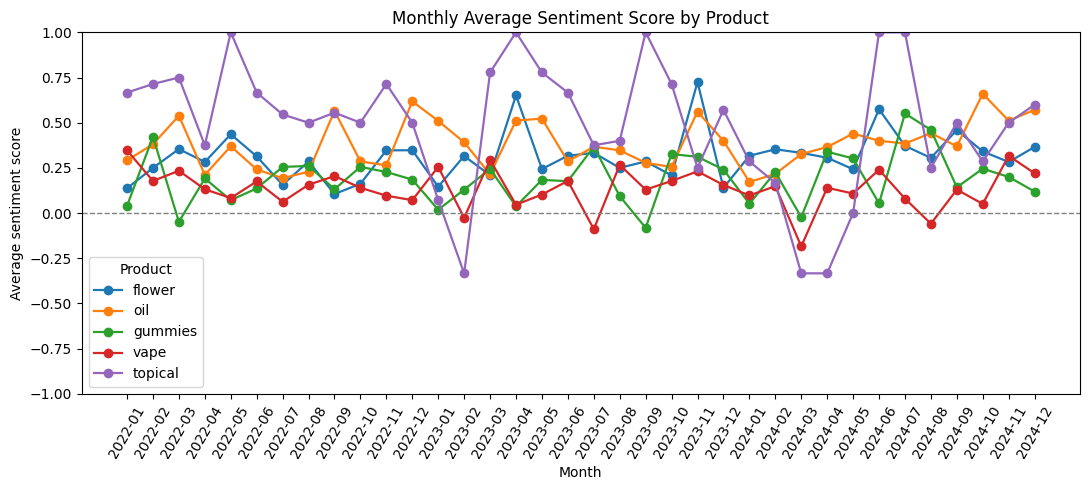

In [29]:
fig, ax = plt.subplots(figsize=(11, 5))
for product in PRODUCT_ORDER:
    ax.plot(monthly_score_wide.index, monthly_score_wide[product], marker='o', linewidth=1.6, label=product)

ax.axhline(0, linestyle='--', color='gray', linewidth=1)
ax.set_title('Monthly Average Sentiment Score by Product')
ax.set_xlabel('Month')
ax.set_ylabel('Average sentiment score')
ax.set_ylim(-1, 1)
ax.legend(title='Product')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

## 9. Main Takeaways

Use the exported tables in `data/processed/final/analysis_outputs/` for reporting. The analysis is based only on the cleaned pair-level dataset, where each row is one product-specific sentiment pair.


In [30]:
top_products = product_counts.sort_values('n_pairs', ascending=False).head(3)
positive_share = product_sentiment_share['positive'].sort_values(ascending=False)
negative_share = product_sentiment_share['negative'].sort_values(ascending=False)

print('Top products by pair volume:')
display(top_products)

print('Highest positive share by product:')
display(positive_share.rename('positive_share').reset_index())

print('Highest negative share by product:')
display(negative_share.rename('negative_share').reset_index())

print(f'Analysis tables written to: {OUT_DIR}')

Top products by pair volume:


,product,n_pairs,share
1,oil,1816,0.258285
2,gummies,1812,0.257716
3,vape,1609,0.228844


Highest positive share by product:


,product,positive_share
0,topical,0.648402
1,oil,0.604075
2,flower,0.568254
3,gummies,0.511038
4,vape,0.476072


Highest negative share by product:


,product,negative_share
0,vape,0.339341
1,gummies,0.322296
2,flower,0.255873
3,oil,0.225771
4,topical,0.146119


Analysis tables written to: data/final/analysis_outputs
